# <span style="color:yellow;">Color Constancy: Correcting Lighting Effects in Images</span>

* The ability to perceive an object's true color despite varying lighting (e.g., a white shirt looks white in both sunlight and indoor light).
* Maintains consistent color perception regardless of light color, intensity, or type.
* In computer vision: Algorithms that correct lighting biases to preserve true object colors.

# Step 1: Import Required Libraries

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from matplotlib.cbook import get_sample_data

In [5]:
sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


# Step 2: Load and Prepare Lena Image

In [6]:
# img_path = get_sample_data('lena.jpeg')
img_path = 'xh.jpg'
img_rgb = plt.imread(img_path)

In [7]:
# Resize to max 128x128
max_size = 128
h, w = img_rgb.shape[:2]
if h > max_size or w > max_size:
    scale = max_size / max(h, w)
    img_rgb = cv2.resize(img_rgb, (int(w * scale), int(h * scale)))

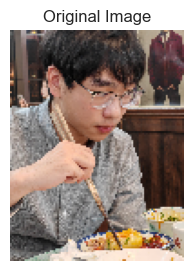

In [8]:
plt.figure(figsize=(4, 3))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [9]:
# Convert to HSV (using float32 to avoid uint8 limitations)
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
print(f"Image shape: {img_rgb.shape}")
print("HSV image stored as float32 to handle negative values during hue shifts")

Image shape: (128, 96, 3)
HSV image stored as float32 to handle negative values during hue shifts


# Step 3: Lighting Simulation Function

![Before and After](Before_and_After.jpg)<br>
Bad versus better white balance, among other things. Saint Vincent de Paul Chapel, in Shrewsbury, Missouri.<br>
https://therefractedlight.blogspot.com/2011/09/white-balance-part-2-gray-world.html

In [10]:
def simulate_lighting(hue_shift=0, value_scale=1.0):
    """
    Simulate different lighting conditions with proper handling of hue shifts.
    
    Parameters:
    hue_shift: Shift in hue (positive = warmer, negative = cooler)
    value_scale: Scale factor for brightness
    """
    # Create a copy of the HSV image (using float32 to avoid overflow)
    modified_hsv = img_hsv.copy()
    
    # Apply hue shift with proper wrapping (handles negative values)
    # Convert to 0-360 range first, shift, then convert back to 0-179
    modified_hsv[:, :, 0] = (modified_hsv[:, :, 0] * (360/180))  # 0-179 → 0-359
    modified_hsv[:, :, 0] = (modified_hsv[:, :, 0] + hue_shift) % 360  # Apply shift
    modified_hsv[:, :, 0] = modified_hsv[:, :, 0] * (180/360)  # 0-359 → 0-179
    
    # Apply brightness scaling
    modified_hsv[:, :, 2] = np.clip(modified_hsv[:, :, 2] * value_scale, 0, 255)
    
    # Convert back to uint8 and then to RGB
    modified_hsv_uint8 = modified_hsv.astype(np.uint8)
    modified_rgb = cv2.cvtColor(modified_hsv_uint8, cv2.COLOR_HSV2RGB)
    
    return modified_rgb

In [11]:
# Test the fixed function with different lighting conditions
warm_img = simulate_lighting(hue_shift=15, value_scale=0.9)    # Warm/yellow
cool_img = simulate_lighting(hue_shift=-20, value_scale=0.9)   # Cool/blue
dim_img = simulate_lighting(hue_shift=0, value_scale=0.5)      # Dim

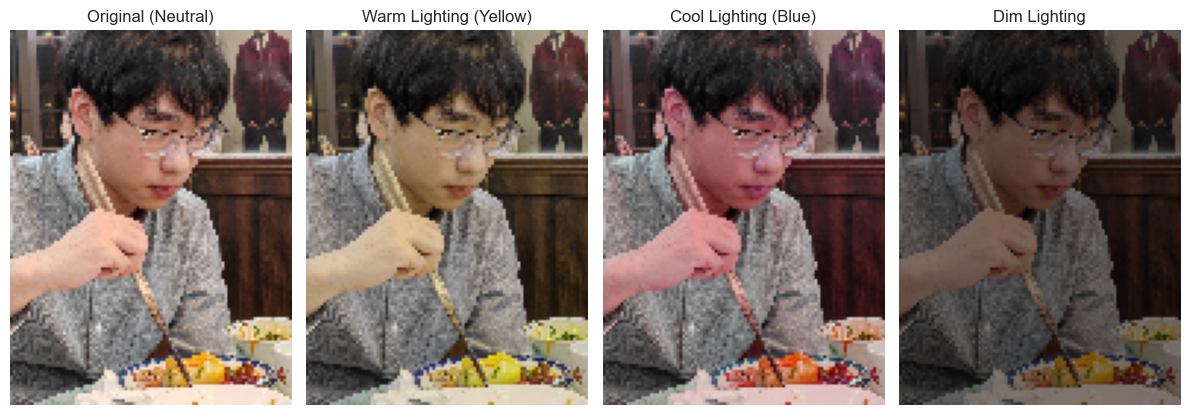

In [12]:
# Display results
fig, axes = plt.subplots(1, 4, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Original (Neutral)")
axes[0].axis("off")

axes[1].imshow(warm_img)
axes[1].set_title("Warm Lighting (Yellow)")
axes[1].axis("off")

axes[2].imshow(cool_img)
axes[2].set_title("Cool Lighting (Blue)")
axes[2].axis("off")

axes[3].imshow(dim_img)
axes[3].set_title("Dim Lighting")
axes[3].axis("off")

plt.tight_layout()
plt.show()

# Step 4: Color Constancy Algorithms

## Step 4.1: Gray World Assumption

1. For an image with $H$ rows, $W$ columns, and normalized RGB values $(I_{norm}\in[0,1])$. 
2. Calculate mean of each RGB channel $\left(\mu_R,\mu_G,\mu_B\right)$ across the image.
3. Compute target gray mean $$\mu_{gray}=\frac{\mu_R+\mu_G+\mu_B}{3}$$
4. Scale each channel to match $\mu_{gray}$ with gain: $$k_c=\frac{\mu_{gray}}{\mu_c},(c={R,G,B})$$
$$I_{corrected}=I_{norm}\times k_c$$
5. Key: Make RGB channel averages equal via $k_c$.

* The `gray world assumption` is a color correction method based on the idea that the average color of a natural scene is neutral gray. 
* Algorithms calculate the mean red, green, and blue values across the image, then scale each channel to make these means equal. 
* This removes color tints from lighting by balancing the overall color average.

In [13]:
def gray_world_correction(img):
    img_float = img.astype(np.float32) / 255.0
    mean_r = np.mean(img_float[:, :, 0])
    mean_g = np.mean(img_float[:, :, 1])
    mean_b = np.mean(img_float[:, :, 2])
    mean_gray = (mean_r + mean_g + mean_b) / 3.0
    
    corrected = img_float.copy()
    corrected[:, :, 0] = corrected[:, :, 0] * (mean_gray / mean_r) if mean_r > 0 else corrected[:, :, 0]
    corrected[:, :, 1] = corrected[:, :, 1] * (mean_gray / mean_g) if mean_g > 0 else corrected[:, :, 1]
    corrected[:, :, 2] = corrected[:, :, 2] * (mean_gray / mean_b) if mean_b > 0 else corrected[:, :, 2]
    
    return (np.clip(corrected, 0, 1) * 255).astype(np.uint8)

## Step 4.2: Whilte Patch Assumption

* The `white patch assumption` corrects colors using the brightest area in a scene, assumed to be white (which reflects all light wavelengths equally). 
* It scales color channels so this "white patch" reaches full intensity, using it as a reference to neutralize lighting tints. 
* All other colors are adjusted relative to this corrected white.

In [14]:
def white_patch_correction(img):
    img_float = img.astype(np.float32) / 255.0
    max_r = np.max(img_float[:, :, 0])
    max_g = np.max(img_float[:, :, 1])
    max_b = np.max(img_float[:, :, 2])
    
    corrected = img_float.copy()
    corrected[:, :, 0] = corrected[:, :, 0] / max_r if max_r > 0 else corrected[:, :, 0]
    corrected[:, :, 1] = corrected[:, :, 1] / max_g if max_g > 0 else corrected[:, :, 1]
    corrected[:, :, 2] = corrected[:, :, 2] / max_b if max_b > 0 else corrected[:, :, 2]
    
    return (corrected * 255).astype(np.uint8)

In [15]:
def simple_color_balance(img, percent=1):
    """Enhance contrast by stretching color ranges"""
    img_float = img.astype(np.float32)
    corrected = np.zeros_like(img_float)
    
    for channel in range(3):
        # Find intensity percentiles to avoid outliers
        low_val = np.percentile(img_float[:, :, channel], percent)
        high_val = np.percentile(img_float[:, :, channel], 100 - percent)
        
        # Clip and normalize to full range
        corrected_channel = np.clip(img_float[:, :, channel], low_val, high_val)
        corrected[:, :, channel] = (corrected_channel - low_val) / (high_val - low_val + 1e-8) * 255
    
    return corrected.astype(np.uint8)

## Step 4.3: Relationship Between Gray-World, White-Patch, and White Balance

All three concepts are closely related to color correction but differ in scope:

* `White balance` is the general goal: Removing color casts from an image so that neutral colors (like white or gray) appear truly neutral, regardless of the lighting conditions (e.g., warm indoor light or cool daylight).


* `Gray world assumption` and `white patch` assumption are specific algorithms used to achieve white balance:
    * The `gray world` algorithm assumes the average color of a scene is neutral gray, balancing RGB channel means to match this average.
    * The `white patch` algorithm assumes the brightest pixels in a scene are white, scaling RGB channels so these pixels reach maximum intensity.
* `White balance` is the overarching objective, while `gray world` and `white patch` are practical methods to accomplish it, each with its own assumptions about scene properties.

# Step 5: Apply Corrections

In [16]:
print("Applying corrections to warm, cool, and dim lighting...")

Applying corrections to warm, cool, and dim lighting...


In [17]:
# Correct warm image
warm_corrected_gray = gray_world_correction(warm_img)
warm_corrected_white = white_patch_correction(warm_img)

In [18]:
# Correct cool image
cool_corrected_gray = gray_world_correction(cool_img)
cool_corrected_white = white_patch_correction(cool_img)

In [19]:
# Correct dim image
dim_corrected_white = white_patch_correction(dim_img)  # Best for brightness recovery
dim_corrected_balance = simple_color_balance(dim_img)  # Enhances contrast

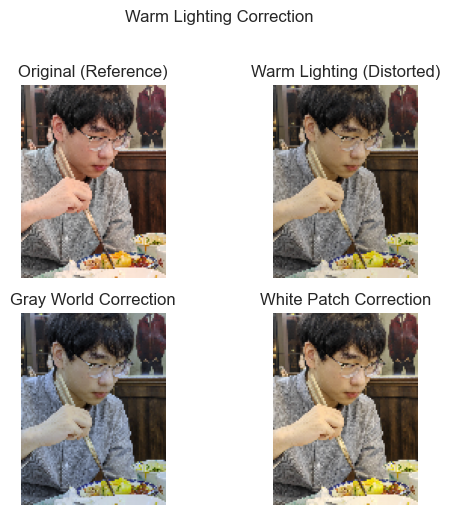

In [20]:
# Display warm lighting corrections
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original (Reference)")
axes[0, 0].axis("off")

axes[0, 1].imshow(warm_img)
axes[0, 1].set_title("Warm Lighting (Distorted)")
axes[0, 1].axis("off")

axes[1, 0].imshow(warm_corrected_gray)
axes[1, 0].set_title("Gray World Correction")
axes[1, 0].axis("off")

axes[1, 1].imshow(warm_corrected_white)
axes[1, 1].set_title("White Patch Correction")
axes[1, 1].axis("off")

plt.suptitle("Warm Lighting Correction", y=1.02)
plt.tight_layout()
plt.show()

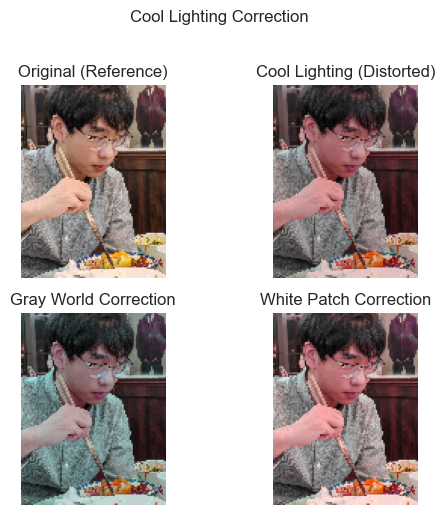

In [21]:
# Display cool lighting corrections
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original (Reference)")
axes[0, 0].axis("off")

axes[0, 1].imshow(cool_img)
axes[0, 1].set_title("Cool Lighting (Distorted)")
axes[0, 1].axis("off")

axes[1, 0].imshow(cool_corrected_gray)
axes[1, 0].set_title("Gray World Correction")
axes[1, 0].axis("off")

axes[1, 1].imshow(cool_corrected_white)
axes[1, 1].set_title("White Patch Correction")
axes[1, 1].axis("off")

plt.suptitle("Cool Lighting Correction", y=1.02)
plt.tight_layout()
plt.show()

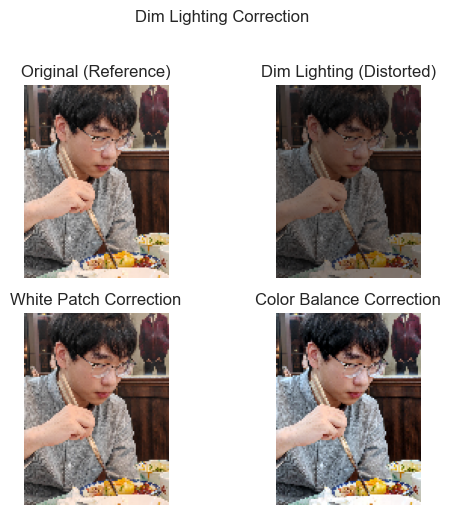

In [22]:
# Display dim lighting corrections
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Original (Reference)")
axes[0, 0].axis("off")

axes[0, 1].imshow(dim_img)
axes[0, 1].set_title("Dim Lighting (Distorted)")
axes[0, 1].axis("off")

axes[1, 0].imshow(dim_corrected_white)
axes[1, 0].set_title("White Patch Correction")
axes[1, 0].set_xlabel("Restores brightness using brightest pixels")
axes[1, 0].axis("off")

axes[1, 1].imshow(dim_corrected_balance)
axes[1, 1].set_title("Color Balance Correction")
axes[1, 1].set_xlabel("Expands intensity range for better contrast")
axes[1, 1].axis("off")

plt.suptitle("Dim Lighting Correction", y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# Quantitative comparison: Intensity range analysis
def get_intensity_range(img):
    """Calculate min and max intensity across all channels"""
    return (np.min(img), np.max(img))

In [24]:
print("\nIntensity Range Analysis (0-255):")
print(f"Original image: {get_intensity_range(img_rgb)}")
print(f"Dim image (uncorrected): {get_intensity_range(dim_img)}")
print(f"Dim image (white patch corrected): {get_intensity_range(dim_corrected_white)}")
print(f"Dim image (color balance corrected): {get_intensity_range(dim_corrected_balance)}")


Intensity Range Analysis (0-255):
Original image: (0, 255)
Dim image (uncorrected): (0, 127)
Dim image (white patch corrected): (0, 255)
Dim image (color balance corrected): (0, 255)
